In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.io as io
import sys
from tqdm import tqdm
import numpy as np

global_path = "/home/ids/edabier/HSU"
# global_path = "/home/edabier/Documents/Thèse/benchmark"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils
from src.utils import plots
from src.models import models
from src.models import foundation_models as rsfm

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

Using device: cuda:0


In [38]:
dataset = "samson"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
A_init = utils.oneD_to_2d(A_flat)
H = Y_init.shape[-1]
Y_init = Y_init.unsqueeze(0)
A = A_init.unsqueeze(0)

with open(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt", "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

fm, Y_up, new_H = rsfm.create_fm("DOFA", Y_init, n_features=1, use_cls=False, extend_cls=False, path=global_path, patch_size=16)
features = rsfm.get_dofa_features(fm, Y_up, wavelengths)
D = int(features.shape[0]/1)
alpha = int(features.shape[1]**0.5)
unmixer = rsfm.Unmixing_from_features(D=D, alpha=alpha, B=B, c=c, n_features=1, use_cls=False)

In [39]:
def train_model(Y, fm, B, c, D, alpha, new_H):
    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))
    
    model = rsfm.Unmixing_from_features(D=D, alpha=alpha, H=new_H, B=B, c=c, n_features=1, use_cls=False, is_cnnaeu=False)
    compiled_model = torch.compile(model)
    compiled_model.apply(model.weights_init)
    compiled_model = models.init_decoder_weights(compiled_model, Y/Y.max(), c, is_unmixer=True, normalize=False)

    compiled_model = compiled_model.to(dev)
    optimizer = build_optim_wrapper(compiled_model, optim_wrapper)

    for epoch in range(epochs):

        optimizer.zero_grad()
        Y = Y.to(dev)
        
        _, features = rsfm.extract_f(fm, Y, new_H, wavelengths, use_cls=False)
        E_hat, A_hat, Y_hat = compiled_model(features)
        W_ab, W_mse, W_tv_e, W_tv_a, W_e = 0.6, 0.09, 3e-5, 0, 0
        loss, _, _, _, _, _, _ = compiled_model.loss(Y, Y_hat, A_hat, E_hat, 1, W_ab, W_tv_e, W_tv_a, W_mse, W_e)
        
        loss.backward()
        nn.utils.clip_grad_norm_(compiled_model.parameters(), max_norm=10, norm_type=1)
        optimizer.step()

        with torch.no_grad():
            constraints = models.weightConstraint()
            compiled_model.decoder.apply(constraints)
    

    compiled_model.eval()

    with torch.no_grad():
        _, _, features = rsfm.extract_f(fm, Y, new_H, wavelengths, A,use_cls=False)
        E_hat, A_hat, _ = compiled_model(features)
    
    return E_hat, A_hat

In [ ]:
padding = 2

n_xp = 10
E_hats_pad, A_hats_pad, E_hats_base, A_hats_base = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, H+2*padding, H+2*padding), torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, H, H)
sads_base, mses_base, sads_pad, mses_pad = [], [], [], []

for n in range(n_xp):
    Y_padded = F.pad(Y_init, pad=(padding, padding, padding, padding), mode="reflect")
    A_hat_padded = torch.zeros(1, c, H+2*padding,H+2*padding)
    weights = torch.zeros_like(A_hat_padded)

    E_hats = torch.zeros((2*padding+1)**2, B, c)

    for i in tqdm(range(2*padding + 1)):
        for j in range(2*padding + 1):

            Y_crop = Y_padded[:, :, i:i+H, j:j+H]
            
            # print(f"Training n°{i+j}/{(2*padding+1)**2}")
            E_hat, A_hat = train_model(Y_crop, fm, B, c, D, alpha, H)

            E_hats[i+j] = E_hat
            A_hat_padded[:, :, i:i+H, j:j+H] += A_hat
            weights[:, :, i:i+H, j:j+H] += 1

    A_hat_padded /= weights
    E_hat_m = torch.mean(E_hats, dim=0)
    E_hats_pad[n] = E_hat_m
    A_hats_pad[n] = A_hat_padded

    E_hat_base, A_hat_base = train_model(Y_init, fm, B, c, D, alpha, H)
    E_hats_base[n] = E_hat_base
    A_hats_base[n] = A_hat_base

    sad_base, _, mse_base = plots.compute_metrics_and_plot(E_hat_base, A_hat_base[:,:,padding:-1-padding, padding:-1-padding], A_init[:,padding:-1-padding, padding:-1-padding], E_init, normalize_E=True, normalize_A=True, return_results=True, plot_A=False, plot_E=False)
    sad_pad, _, mse_pad = plots.compute_metrics_and_plot(E_hat_m, A_hat_padded[:,:,padding*2:-1-2*padding, padding*2:-1-2*padding], A_init[:,padding:-1-padding, padding:-1-padding], E_init, normalize_E=True, normalize_A=True, return_results=True, plot_A=False, plot_E=False)
    sads_base.append(sad_base)
    mses_base.append(mse_base)
    sads_pad.append(sad_pad)
    mses_pad.append(mse_pad)

print(f"Multi-crop: SAD = {torch.mean(torch.tensor(sads_pad))} ± {torch.std(torch.tensor(sads_pad))}, NMSE = {torch.mean(torch.tensor(mses_pad))} ± {torch.std(torch.tensor(mses_pad))}")
print(f"Base: SAD = {torch.mean(torch.tensor(sads_base))} ± {torch.std(torch.tensor(sads_base))}, NMSE = {torch.mean(torch.tensor(mses_base))} ± {torch.std(torch.tensor(mses_base))}")

  0%|          | 0/5 [00:00<?, ?it/s]

{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14


In [ ]:
# padding = 4
# Y_padded = F.pad(Y_init, pad=(padding, padding, padding, padding), mode='reflect')

# shifts = [i for i in range(-padding, padding+1)]
# crops = []

# for x_i in shifts:
#     for y_i in shifts:
#         crop = Y_padded[0, 0, padding+x_i:padding+x_i+new_H, padding+y_i:padding+y_i+new_H]
#         crops.append(crop)

# print(f"Generated {len(crops)} crops from the padded image")

# '''
# General idea:
# Train one model on each crop independently, and average each prediction of the crop 
# The average must be weighted by how many prediction of the current pixel's were done before
# For ex if a pixel was present in 3 previous crops, we weight the current A_hat at this pixel by 3 and just 1 for the new prediction at this pixel
# To do this, we create a blank A_hat and a blank weight matrix, and update the A_hat by averaging, and the weight by adding 1 each time we average

# Create a padded blank image (A_hat_padded = torch.zeros_like(Y_padded))
# Create a padded blank weight image (weight_padded = torch.zeros_like(Y_padded))

# loop over x_i
#     loop over y_i
#         train a model on the [x_i, y_i] crop

#         loop over padded pixels:
#             if weight_padded[x,y] = 0:
            
#                 /!\ not sure here of how to fill A_hat_padded
            
#                 A_hat_padded[x,y] =  A_hat[x+x_i, y+y_i]
            
#                 weight_padded[x,y] += 1
#             else:
#                 average the current A_hat_padded pixel and the current A_hat pixel with the weighting
#                 A_hat_padded[x,y] = weight_padded[x,y] * A_hat_padded[x,y] + A_hat[x,y]

# A_hat_padded_center = A_hat_padded[2*padding:-1-2*padding, 2*padding:-1-2*padding] <=> only the center pixels where there is the most averaging

# return A_hat_padded, A_hat_padded_center
# '''

# '''
# Create a tensor A_hats of shape [H+2pad, W+2pad] that contains empty lists at each pixel

# loop over x_i
#     loop over y_i
#         train model on Y_padded[x_i, y_i]

#         A_hats[x_i, y_i].append(A_hat[x_i, y_i])

# Average the A_hats pixels by averaging the lists 
# (if a pixel of A_hats has a list of 1 element, it been predicted by only 1 crop
# If it has more than 1 element, it has been predicted by several crops)

# return the averaged A_hats and the central one containing the most averaged pixels
# '''

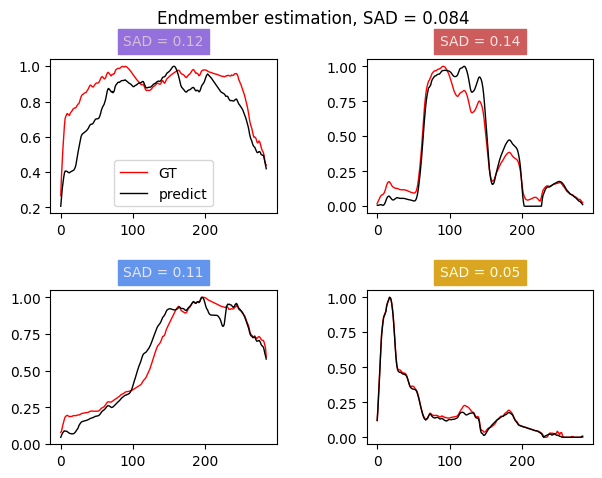

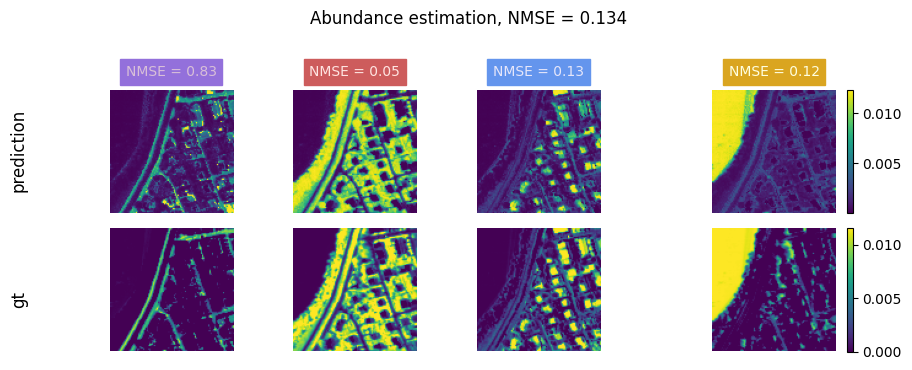

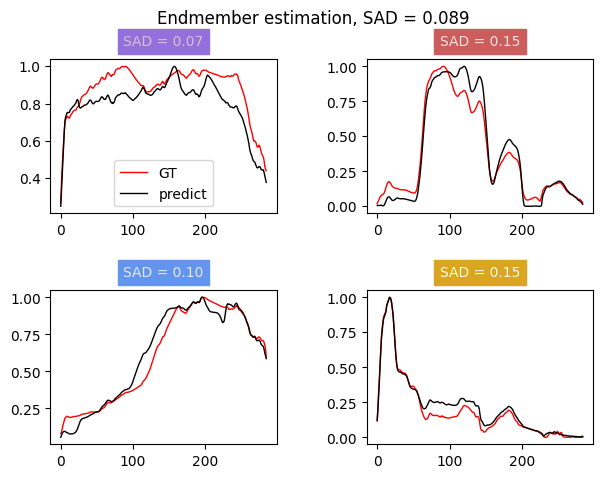

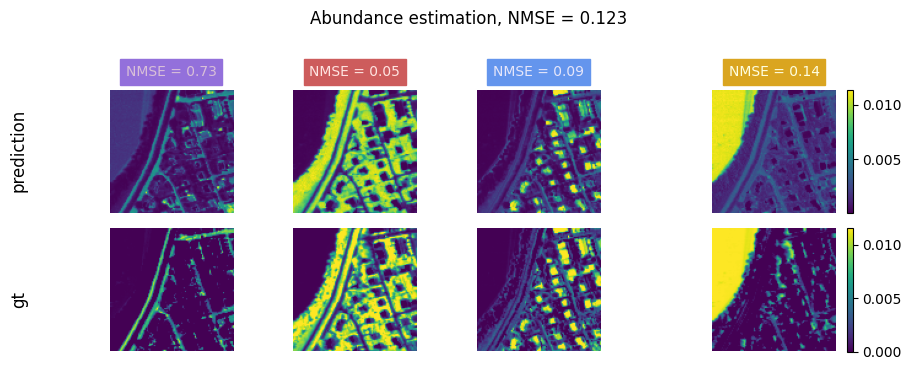

In [ ]:
sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat_base, A_hat_base[:,:,padding:-1-padding, padding:-1-padding], A_init[:,padding:-1-padding, padding:-1-padding], E_init, normalize_E=True, normalize_A=True, return_results=True)
sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_padded[:,:,padding*2:-1-2*padding, padding*2:-1-2*padding], A_init[:,padding:-1-padding, padding:-1-padding], E_init, normalize_E=True, normalize_A=True, return_results=True)